In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import timeit

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

In assignment 1 we are presenting gradient boosting algorithm builded from scratch for regression applications.
We are use idea from lecture in 3. section "Advanced Boosting: Gradient Boosting Framework". Tasks starts with loading dataset and preseting head of the file, then we drop categorical.

In [8]:
house_prices = pd.read_csv('./../datasets/california-housing-prices.csv')
house_prices.drop(columns=['ocean_proximity'], inplace=True)

print(f"Before dropping nan values: {house_prices.shape}")
house_prices.dropna(inplace=True)
print(f"After dropping nan values: {house_prices.shape}")

house_prices.head()

Before dropping nan values: (20640, 9)
After dropping nan values: (20433, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0


Then we divide our dataset into train, val and tests subsets, where predicted value will be median_house_value

In [9]:
random_state = 42

def load_data(house_prices, random_state=random_state, test_size=0.2):
    X = house_prices.drop(columns=["median_house_value"])
    y = house_prices["median_house_value"]

    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=random_state)

    return X_train, X_val, X_test, y_train, y_val, y_test

X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices)

print(f"Train set shape={X_train.shape}")
print(f"Validation set shape={X_val.shape}")
print(f"Test set shape={X_test.shape}")

Train set shape=(14711, 8)
Validation set shape=(1635, 8)
Test set shape=(4087, 8)


Now we implement <b>the core</b>. According to the lecture, for squared error loss the negative gradient is equal to residuals
$$
r_{im} = - \left. \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right|_{F = F_{m-1}} =  y_{real}-F(x).
$$

Like it was said on the laboratory, we try to this in oop. Additionally in the lecture there is point "3. Compute optimal step size:" (3.1.1. Steepest descent in function space), but on laboratory it was said we skip that.

In [ ]:
class SimpleGradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, random_state=random_state):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        self.init_ = y.mean()
        self.estimators_ = []
        self.train_rmse_ = []

        current_prediction = np.full(len(y), self.init_, dtype=float)

        # 0. Thus, at each iteration we:
        for i in range(self.n_estimators):
            # 1. Compute pseudo-residuals: 
            residuals = y - current_prediction

            # 2. Fit a base learner
            weak_learner = DecisionTreeRegressor(
                max_depth=1,
                random_state=self.random_state + i
            )
            weak_learner.fit(X, residuals)

            # 4. Update
            update = weak_learner.predict(X)
            current_prediction = current_prediction + self.learning_rate * update

            self.estimators_.append(weak_learner)

            rmse = np.sqrt(mean_squared_error(y, current_prediction))
            self.train_rmse_.append(rmse)

        return self

    def predict(self, X):
        X = np.asarray(X)

        prediction = np.full(X.shape[0], self.init_, dtype=float)

        for weak_learner in self.estimators_:
            prediction += self.learning_rate * weak_learner.predict(X)

        return prediction

Code written that way allows us to optimize two parameters: number of estimators and learning rate. So we test a few values and compare models. (this code can run sometime)

In [11]:
param_grid = [
    (0.05, 300),
    (0.10, 50),
    (0.10, 300),
    (0.3, 50),
    (0.3, 300),
    (0.5, 300),
    (0.7, 300),
    (0.7, 600),
    (0.85, 300),
]

random_seeds = [42, 67, 100, 101, 500]
results = []

for learning_rate, n_estimators in param_grid:
    rmse = np.zeros(len(random_seeds))
    mae = np.zeros(len(random_seeds))
    r2 = np.zeros(len(random_seeds)) 

    for i, random_seed in enumerate(random_seeds):
        model = SimpleGradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=random_seed
        )

        X_train, X_val, _, y_train, y_val, __ = load_data(house_prices, random_state=random_seed)

        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)

        rmse[i] = np.sqrt(mean_squared_error(y_val, val_pred))
        mae[i] = mean_absolute_error(y_val, val_pred)
        r2[i] = r2_score(y_val, val_pred)

    results.append({
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "val_rmse": np.mean(rmse),
        "val_mae": np.mean(mae),
        "val_r2": np.mean(r2)
    })

results_df = pd.DataFrame(results).sort_values("val_rmse").reset_index(drop=True)
results_df

,learning_rate,n_estimators,val_rmse,val_mae,val_r2
0,0.70,600,57009.296791,40916.265310,0.757286
1,0.85,300,57788.565331,41505.586503,0.750603
2,0.70,300,57997.148064,41737.558357,0.748824
3,0.50,300,58804.895333,42382.016220,0.741780
4,0.30,300,60381.285969,43532.939115,0.727735
5,0.10,300,66552.928077,48829.247022,0.669199
6,0.30,50,70887.469091,52469.721369,0.624697
7,0.05,300,71189.165068,52790.194795,0.621481
8,0.10,50,79146.556381,59952.733303,0.532062


Based on that we choose learning_rate=0.85 and n_estimators=300, 600 isn't much better so we choose less to calculate. After that we join train and validation datasets, so we can better train for testing with the best subset of data.

In [12]:
best_lr = 0.85
best_n_estimators = 300

In [13]:
our_rmse = np.zeros(len(random_seeds))
our_mae = np.zeros(len(random_seeds))
our_r2 = np.zeros(len(random_seeds)) 

for i, random_seed in enumerate(random_seeds):
    model = SimpleGradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed
    )

    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0)
    y_train_final = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_final, y_train_final)
    test_pred = model.predict(X_test)

    our_rmse[i] = np.sqrt(mean_squared_error(y_test, test_pred))
    our_mae[i] = mean_absolute_error(y_test, test_pred)
    our_r2[i] = r2_score(y_test, test_pred)

print("model results")
print("RMSE:", round(our_rmse.mean(), 2))
print("MAE:", round(our_mae.mean(), 2))
print("R2:", round(our_r2.mean(), 2))

our_model = model

model results
RMSE: 58689.93
MAE: 41530.92
R2: 0.74


And let's add some visualizations

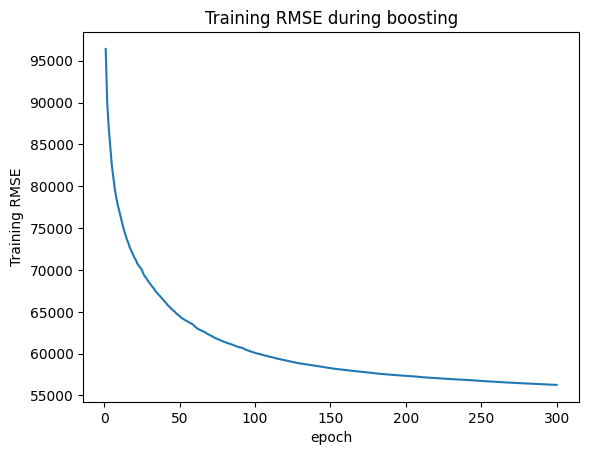

In [14]:
plt.plot(range(1, len(our_model.train_rmse_) + 1), our_model.train_rmse_)
plt.xlabel("epoch")
plt.ylabel("Training RMSE")
plt.title("Training RMSE during boosting")
plt.show()

Now we can finally compare our implementation with imported one from sklearn. Well use the same hyperparameters.

In [15]:
sklearn_rmse = np.zeros(len(random_seeds))
sklearn_mae = np.zeros(len(random_seeds))
sklearn_r2 = np.zeros(len(random_seeds)) 

for i, random_seed in enumerate(random_seeds):
    model = GradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed,
        loss="squared_error",
        max_depth=1
    )

    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0)
    y_train_final = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_final, y_train_final)
    test_pred = model.predict(X_test)

    sklearn_rmse[i] = np.sqrt(mean_squared_error(y_test, test_pred))
    sklearn_mae[i] = mean_absolute_error(y_test, test_pred)
    sklearn_r2[i] = r2_score(y_test, test_pred)

print("sklearn model results")
print("RMSE:", round(sklearn_rmse.mean(), 2))
print("MAE:", round(sklearn_mae.mean(), 2))
print("R2:", round(sklearn_r2.mean(), 2))

sklearn model results
RMSE: 58689.93
MAE: 41530.92
R2: 0.74


Below we present final comparison of our implementation and library implementation.

In [16]:
comparison = pd.DataFrame({
    "model": ["our model", "sklearn"],
    "RMSE": [our_rmse.mean(), sklearn_rmse.mean()],
    "MAE": [our_mae.mean(), sklearn_mae.mean()],
    "R2": [our_r2.mean(), sklearn_r2.mean()]
})

comparison

,model,RMSE,MAE,R2
0,our model,58689.932272,41530.915961,0.740534
1,sklearn,58689.932272,41530.915961,0.740534


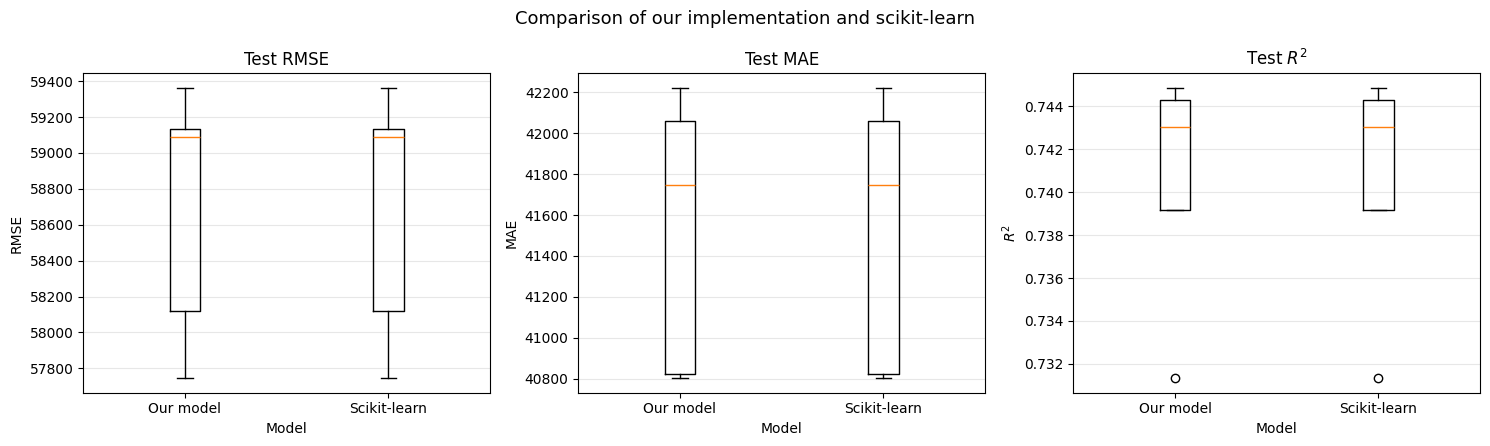

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].boxplot([our_rmse, sklearn_rmse], tick_labels=["Our model", "Scikit-learn"])
axes[0].set_title("Test RMSE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([our_mae, sklearn_mae], tick_labels=["Our model", "Scikit-learn"])
axes[1].set_title("Test MAE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MAE")
axes[1].grid(axis="y", alpha=0.3)

axes[2].boxplot([our_r2, sklearn_r2], tick_labels=["Our model", "Scikit-learn"])
axes[2].set_title("Test $R^2$")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("$R^2$")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Comparison of our implementation and scikit-learn", fontsize=13)
plt.tight_layout()
plt.show()

Our model was build with algorithm based on lecture section 3 about gradient boosting. We started from mean target value, then in each iteration we computed residuals and fitted one decision stump to these residuals. After that model prediction was updated by learning rate multiplied by stump prediction. We also selected best in our search grid two hyperparameters: learning rate and number of estimators.

Then, we compared our own implementation with `scikit-learn` model. Results are identical.


First, to make comparison complete, we also compare computation time. We measure training time and prediction time separately. For each random seed, time was measured 5 times and then averaged.

In [18]:
our_fit_time = np.zeros(len(random_seeds))
our_pred_time = np.zeros(len(random_seeds))
sklearn_fit_time = np.zeros(len(random_seeds))
sklearn_pred_time = np.zeros(len(random_seeds))

for i, random_seed in enumerate(random_seeds):
    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0)
    y_train_final = pd.concat([y_train, y_val], axis=0)

    def fit_our():
        model = SimpleGradientBoostingRegressor(
            n_estimators=best_n_estimators,
            learning_rate=best_lr,
            random_state=random_seed
        )
        model.fit(X_train_final, y_train_final)

    def fit_sklearn():
        model = GradientBoostingRegressor(
            n_estimators=best_n_estimators,
            learning_rate=best_lr,
            random_state=random_seed,
            loss="squared_error",
            max_depth=1
        )
        model.fit(X_train_final, y_train_final)

    our_fit_time[i] = np.mean(timeit.repeat(fit_our, repeat=5, number=1))
    sklearn_fit_time[i] = np.mean(timeit.repeat(fit_sklearn, repeat=5, number=1))

    our_model = SimpleGradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed
    )
    our_model.fit(X_train_final, y_train_final)

    sklearn_model = GradientBoostingRegressor(
        n_estimators=best_n_estimators,
        learning_rate=best_lr,
        random_state=random_seed,
        loss="squared_error",
        max_depth=1
    )
    sklearn_model.fit(X_train_final, y_train_final)

    def predict_our():
        our_model.predict(X_test)

    def predict_sklearn():
        sklearn_model.predict(X_test)

    our_pred_time[i] = np.mean(timeit.repeat(predict_our, repeat=5, number=1))
    sklearn_pred_time[i] = np.mean(timeit.repeat(predict_sklearn, repeat=5, number=1))

Below we present average time results for both models.

In [19]:
time_comparison = pd.DataFrame({
    "model": ["our model", "sklearn"],
    "fit time [s]": [our_fit_time.mean(), sklearn_fit_time.mean()],
    "predict time [s]": [our_pred_time.mean(), sklearn_pred_time.mean()]
})

time_comparison

,model,fit time [s],predict time [s]
0,our model,2.050736,0.023554
1,sklearn,1.949671,0.003629


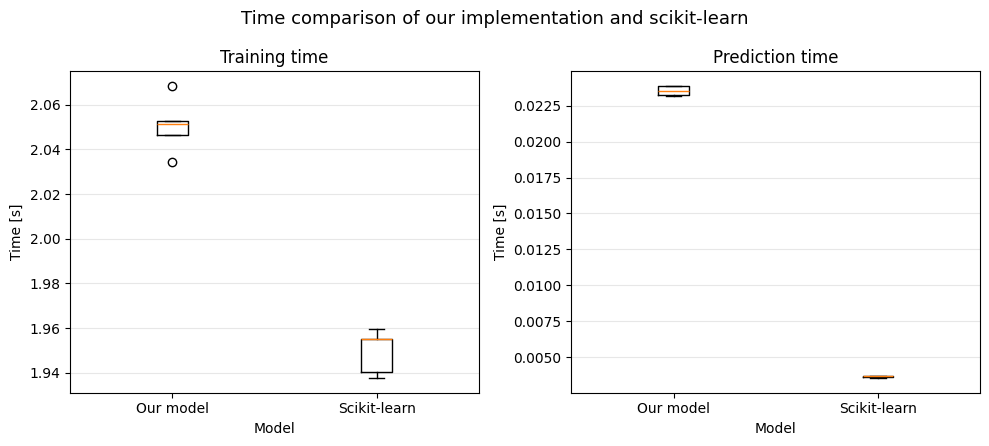

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].boxplot([our_fit_time, sklearn_fit_time], tick_labels=["Our model", "Scikit-learn"])
axes[0].set_title("Training time")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Time [s]")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([our_pred_time, sklearn_pred_time], tick_labels=["Our model", "Scikit-learn"])
axes[1].set_title("Prediction time")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Time [s]")
axes[1].grid(axis="y", alpha=0.3)

fig.suptitle("Time comparison of our implementation and scikit-learn", fontsize=13)
plt.tight_layout()
plt.show()

The predictive performance of both models is the same, so time comparison shows only computational difference between implementations. Exact values depend on hardware and current system load, but we can interprate the differences between two models.

As expected scikit implementation is more optimized than ours, diffrence is small but can play big role if dataset would be bigger.

# 3

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from xgboost import XGBRegressor

Now we build a two-level stacked ensemble. On the first level we use three different models: Random Forest, XGBoost and Neural Network. On the second level we use Ridge Regression as meta-learner.

To train model correctly, we us predictions from cross-validation. In this way, predictions for the second level are created only from models that did not see a given observation during training, so we are avaoiding data leakage.

In [21]:
rf_rmse = np.zeros(len(random_seeds))
rf_mae = np.zeros(len(random_seeds))
rf_r2 = np.zeros(len(random_seeds))

xgb_rmse = np.zeros(len(random_seeds))
xgb_mae = np.zeros(len(random_seeds))
xgb_r2 = np.zeros(len(random_seeds))

nn_rmse = np.zeros(len(random_seeds))
nn_mae = np.zeros(len(random_seeds))
nn_r2 = np.zeros(len(random_seeds))

stack_rmse = np.zeros(len(random_seeds))
stack_mae = np.zeros(len(random_seeds))
stack_r2 = np.zeros(len(random_seeds))

We are making predictions like presented in lecture schema

<center>
    <img src="./../assets/a1/1.png" width="700">
</center>

In [25]:
def get_predictions(rf_model, xgb_model, nn_model, X_train_final, y_train_final, random_seed):
    kf = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    rf_oof = np.zeros(len(X_train_final))
    xgb_oof = np.zeros(len(X_train_final))
    nn_oof = np.zeros(len(X_train_final))

    for train_idx, val_idx in kf.split(X_train_final):
        X_fold_train = X_train_final.iloc[train_idx]
        X_fold_val = X_train_final.iloc[val_idx]
        y_fold_train = y_train_final.iloc[train_idx]

        rf_fold = clone(rf_model)
        xgb_fold = clone(xgb_model)
        nn_fold = clone(nn_model)

        rf_fold.fit(X_fold_train, y_fold_train)
        xgb_fold.fit(X_fold_train, y_fold_train)
        nn_fold.fit(X_fold_train, y_fold_train)

        rf_oof[val_idx] = rf_fold.predict(X_fold_val)
        xgb_oof[val_idx] = xgb_fold.predict(X_fold_val)
        nn_oof[val_idx] = nn_fold.predict(X_fold_val)

    return pd.DataFrame({
        "rf": rf_oof,
        "xgb": xgb_oof,
        "nn": nn_oof
    })

Now we run the full experiment for all random seeds and compare individual models with the stacked ensemble.

<center>
    <img src="./../assets/a1/2.png" width="900">
</center>

In [31]:
for i, random_seed in enumerate(random_seeds):
    X_train, X_val, X_test, y_train, y_val, y_test = load_data(house_prices, random_state=random_seed)

    X_train_final = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
    y_train_final = pd.concat([y_train, y_val], axis=0).reset_index(drop=True)

    rf_model = RandomForestRegressor(
        n_estimators=200,
        random_state=random_seed,
        n_jobs=-1
    )

    xgb_model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=random_seed,
        n_jobs=-1
    )

    nn_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            max_iter=1500,
            random_state=random_seed
        ))
    ])

    meta_model = Ridge(alpha=1.0)

    meta_X_train = get_predictions(
        rf_model,
        xgb_model,
        nn_model,
        X_train_final,
        y_train_final,
        random_seed
    )

    meta_model.fit(meta_X_train, y_train_final)

    rf_model.fit(X_train_final, y_train_final)
    xgb_model.fit(X_train_final, y_train_final)
    nn_model.fit(X_train_final, y_train_final)

    rf_test_pred = rf_model.predict(X_test)
    xgb_test_pred = xgb_model.predict(X_test)
    nn_test_pred = nn_model.predict(X_test)

    meta_X_test = pd.DataFrame({
        "rf": rf_test_pred,
        "xgb": xgb_test_pred,
        "nn": nn_test_pred
    })

    stack_test_pred = meta_model.predict(meta_X_test)

    rf_rmse[i] = np.sqrt(mean_squared_error(y_test, rf_test_pred))
    rf_mae[i] = mean_absolute_error(y_test, rf_test_pred)
    rf_r2[i] = r2_score(y_test, rf_test_pred)

    xgb_rmse[i] = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
    xgb_mae[i] = mean_absolute_error(y_test, xgb_test_pred)
    xgb_r2[i] = r2_score(y_test, xgb_test_pred)

    nn_rmse[i] = np.sqrt(mean_squared_error(y_test, nn_test_pred))
    nn_mae[i] = mean_absolute_error(y_test, nn_test_pred)
    nn_r2[i] = r2_score(y_test, nn_test_pred)

    stack_rmse[i] = np.sqrt(mean_squared_error(y_test, stack_test_pred))
    stack_mae[i] = mean_absolute_error(y_test, stack_test_pred)
    stack_r2[i] = r2_score(y_test, stack_test_pred)

/home/piotr/.pyenv/versions/3.12.9/envs/tensorflow/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/piotr/.pyenv/versions/3.12.9/envs/tensorflow/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/piotr/.pyenv/versions/3.12.9/envs/tensorflow/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1500) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/piotr/.pyenv/versions/3.12.9/envs/tensorflow/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterat

Now we compare the stacked ensemble with individual base models.

In [32]:
comparison = pd.DataFrame({
    "model": ["random forest", "xgboost", "neural network", "stacked ensemble"],
    "RMSE": [rf_rmse.mean(), xgb_rmse.mean(), nn_rmse.mean(), stack_rmse.mean()],
    "MAE": [rf_mae.mean(), xgb_mae.mean(), nn_mae.mean(), stack_mae.mean()],
    "R2": [rf_r2.mean(), xgb_r2.mean(), nn_r2.mean(), stack_r2.mean()]
})

comparison

,model,RMSE,MAE,R2
0,random forest,49277.591035,31934.306468,0.817075
1,xgboost,55502.077594,38478.097589,0.767966
2,neural network,58954.677426,40827.442858,0.737905
3,stacked ensemble,48858.518776,31685.338137,0.820153


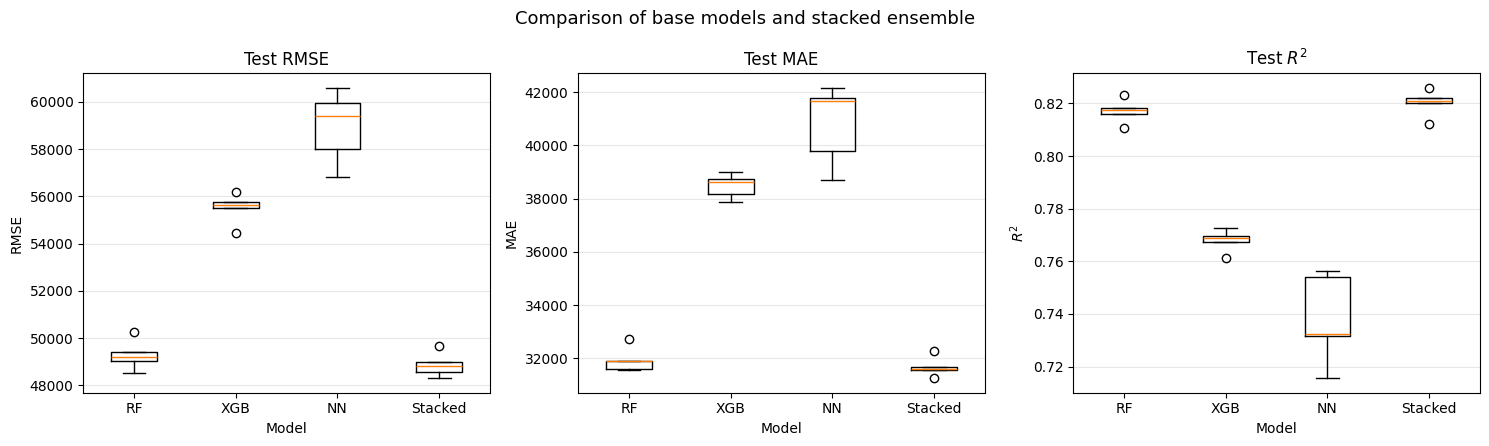

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].boxplot([rf_rmse, xgb_rmse, nn_rmse, stack_rmse], tick_labels=["RF", "XGB", "NN", "Stacked"])
axes[0].set_title("Test RMSE")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE")
axes[0].grid(axis="y", alpha=0.3)

axes[1].boxplot([rf_mae, xgb_mae, nn_mae, stack_mae], tick_labels=["RF", "XGB", "NN", "Stacked"])
axes[1].set_title("Test MAE")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("MAE")
axes[1].grid(axis="y", alpha=0.3)

axes[2].boxplot([rf_r2, xgb_r2, nn_r2, stack_r2], tick_labels=["RF", "XGB", "NN", "Stacked"])
axes[2].set_title("Test $R^2$")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("$R^2$")
axes[2].grid(axis="y", alpha=0.3)

fig.suptitle("Comparison of base models and stacked ensemble", fontsize=13)
plt.tight_layout()
plt.show()

We used a two-level stacked ensemble. First, three different base models were trained: Random Forest, XGBoost and Neural Network. Then, 5-fold cross-validation was used to generate predictions for the training set. These predictions became input features for Ridge Regression on the second level.